In [1]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps.ohm"
base_dir = Path("filtered_data")
data_two = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data_two.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Read data
file = "all_timesteps_high_error.ohm"
base_dir = Path("filtered_data")
data_all_high_error = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "all_timesteps_high_error.ohm" 
        if datei_pfad.exists():
            if str(datei_pfad).startswith('filtered_data\\240610') or str(datei_pfad).startswith('filtered_data\\240704'):
                daten_objekt = pg.load(str(datei_pfad))
                data_all_high_error.append([unterordner.name, daten_objekt])
                print(f"Load data: {datei_pfad}")

# Read data
file = "all_timesteps.ohm"
base_dir = Path("filtered_data")
data_all = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "all_timesteps.ohm" 
        if datei_pfad.exists():
            if str(datei_pfad).startswith('filtered_data\\240610') or str(datei_pfad).startswith('filtered_data\\240704'):
                daten_objekt = pg.load(str(datei_pfad))
                data_all.append([unterordner.name, daten_objekt])
                print(f"Load data: {datei_pfad}")

chi2_oT = []
chi2_wT = []
rrms_oT = []
rrms_wT = []
mod_oT = []
mod_wT = []

for data in [data_two,data_all,data_all_high_error]:
    # Create method manager
    manager = []
    for ts in data:
        manager.append(ert.ERTManager(ts[1], verbose=True))
    
    # Create mesh
    mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
    manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)
    
    # Inversion without temperature correction
    DATA = [dat[1] for dat in data]
    # Full time-lapse
    scalef = 0.6
    fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
    fop.setData(DATA)
    #manager[0].createMesh(quality=34,paraMaxCellSize=20)
    fop.setMesh(mesh)
    print(fop.mesh())  # important to call mesh() function once!
    dataVec = np.concatenate([data["rhoa"] for data in DATA])
    errorVec = np.concatenate([data["err"] for data in DATA])
    startModel = fop.createStartModel(dataVec)
    inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
    model = inv.run(dataVec, errorVec, maxIter=10, lam= 10, startModel=startModel, verbose=True)
    chi2_oT.append(round(inv.chi2(),2))
    rrms_oT.append(round(inv.relrms(),2))
    mod = np.reshape(model, [len(DATA), -1])
    mod_oT.append(mod)
    
    # Temperature correction    
    mod_corr = [] 
    temp_spread = []
    timestep = 0
    ort = 'Langer-Kamp'
    mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
    for count, m in enumerate(mod):
        timestep = count + 11
        dateien = os.listdir(".\Temperature_data/" + ort )
        
        for datei in dateien: 
            if (datei).startswith('T_Profil%s_array' % (str(timestep))):
                Temp_tiefe_vektor = np.load(".\Temperature_data/" + ort + '/' + datei, allow_pickle=True)
        res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
        mod_corr.append(res_new) # Reference inversion
    
    modell2 = np.reshape(mod, -1)
    modell_corr = np.reshape(mod_corr, -1)
    response = inv.fop.response(modell2)
    response_t_corr = inv.fop.response(modell_corr)
    difference = response_t_corr - response
    diff = np.reshape(difference, [len(DATA), -1])
    for h in range(len(diff)):
        DATA[h]['rhoa'] = DATA[h]['rhoa'] + diff[h]
        
        
    # Inversion with temperature correction
    # Full time-lapse
    scalef = 0.6
    fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
    fop.setData(DATA)
    fop.setMesh(mesh)
    print(fop.mesh())  # important to call mesh() function once!
    dataVec = np.concatenate([data["rhoa"] for data in DATA])
    errorVec = np.concatenate([data["err"] for data in DATA])
    startModel = fop.createStartModel(dataVec)
    inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
    model = inv.run(dataVec, errorVec, maxIter=10, lam= 10, startModel=startModel, verbose=True)
    chi2_wT.append(round(inv.chi2(),2))
    rrms_wT.append(round(inv.relrms(),2))
    mod_Tcorr = np.reshape(model, [len(DATA), -1])
    mod_wT.append(mod_Tcorr)


[NbConvertApp] Converting notebook Hilfsfunktionen.ipynb to script
[NbConvertApp] Writing 24887 bytes to Hilfsfunktionen.py


Load data: filtered_data\240610\two_timesteps.ohm
Load data: filtered_data\240704\two_timesteps.ohm
Load data: filtered_data\240610\all_timesteps_high_error.ohm
Load data: filtered_data\240704\all_timesteps_high_error.ohm
Load data: filtered_data\240610\all_timesteps.ohm
Load data: filtered_data\240704\all_timesteps.ohm


02/09/25 - 02:09:06 - pyGIMLi - INFO - Found 2 regions.
02/09/25 - 02:09:06 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
02/09/25 - 02:09:06 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/09/25 - 02:09:06 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/09/25 - 02:09:07 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
02/09/25 - 02:09:07 - pyGIMLi - INFO - Use median(data values)=106.19
02/09/25 - 02:09:07 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=106.190000/106.190000
02/09/25 - 02:09:07 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000133E304F420>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x00000133E304F6F0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000133E304F560>
min/max (data): 21.65/1126
min/max (error): 10.1%/10.15%
min/max (start model): 106/106
--------------------------------------------------------------------------------


02/09/25 - 02:09:39 - pyGIMLi - INFO - Found 2 regions.
02/09/25 - 02:09:39 - pyGIMLi - INFO - Region with smallest marker (1) set to background
02/09/25 - 02:09:39 - pyGIMLi - INFO - Creating forward mesh from region infos.


...

fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000133E304FBF0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x00000133E3061770>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000133E3084950>
min/max (data): 2.42/2703
min/max (error): 8.7%/1.0e+06%
min/max (start model): 99.47/99.47
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   66.43
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    7.02 (dPhi = 87.10%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.98 (dPhi = 43.35%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.40 (dPhi = 4.40%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    2.35 (dPhi = 0.20%) lam: 10.0
##########

02/09/25 - 02:25:48 - pyGIMLi - INFO - Found 2 regions.
02/09/25 - 02:25:48 - pyGIMLi - INFO - Region with smallest marker (1) set to background
02/09/25 - 02:25:48 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/09/25 - 02:25:49 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/09/25 - 02:25:49 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


02/09/25 - 02:25:51 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000133E28B3100>
Data transformation: <pgcore._pygimli_.RTrans object at 0x00000133E30625E0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000133E28ED580>
min/max (data): -25.66/2693
min/max (error): 8.7%/1.0e+06%
min/max (start model): 79.22/79.22
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  107.58
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    9.85 (dPhi = 89.34%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    4.67 (dPhi = 41.45%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.88 (dPhi = 4.97%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    3.78 (dPhi = 0.37%) lam: 10.0
########

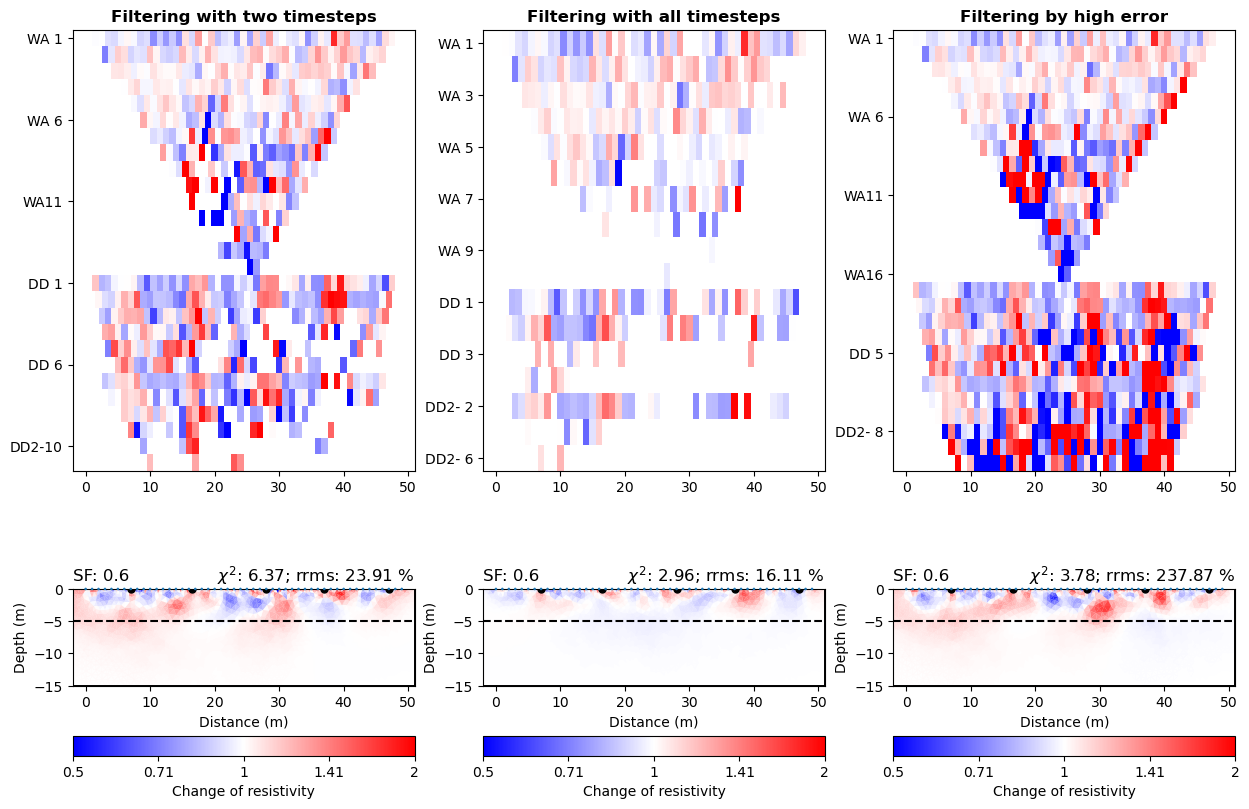

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=3, height_ratios=[4, 2],figsize=(15, 10))
title_list = ['Filtering with two timesteps', 'Filtering with all timesteps', 'Filtering by high error']
for (nr, result), data, chi, rrms, title in zip(enumerate(mod_wT), [data_two,data_all,data_all_high_error], chi2_wT, rrms_wT, title_list):
    gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[4, 2])  # Höhe des zweiten Subplots verdoppelt
    
    #datum = datetime.strptime(data[0], '%y%m%d')
    bild1 = ert.show(data[1][1], (data[1][1]['rhoa'])/data[0][1]['rhoa'], ax= axs[0,nr], cMin=0.5, cMax=2, cMap= 'bwr', logScale= True,label = 'Change of app. resistivity');
    axs[0,nr].set_title(title, fontweight='bold')
    axs[0,nr].set_xlim(-2, 51) 
    cb1 = bild1[-1]
    cb1.remove() 
    
    ratio =result[1] / result[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[1, nr], label = 'Change of resistivity', logScale= True) 
    axs[1, nr].set_title('$\chi^2$: '+ str(chi) + '; rrms: '+ str(rrms)+ ' %',  loc = 'right')
    axs[1, nr].set_title('SF: '+ str(0.6), loc = 'left')
    # Langer Kamp
    tree_postions = [7, 16.5, 28, 37, 47]
    for x in tree_postions:
        axs[1, nr].plot(x, 0, '.', markersize=10, color='black')
    axs[1, nr].axhline(y=-5, color='k', linestyle='--')
    #axs[axnr, 0].axhline(y=-5, color='k', linestyle='--')
    axs[1, nr].set_ylim(-15, 0) 
    
    plt.subplots_adjust(hspace=0.01) 
    
    axs[1, nr].set_xlabel('Distance (m)')
    axs[1, nr].set_ylabel('Depth (m)')
fig.savefig('./Fig12/' + '/comparison_filtering.png' , bbox_inches = 'tight', dpi=300)